# Node Attribute Outlier Analysis

Checks distributions of static junction and pipe attributes across all 500 LeakDB (Hanoi-CMH) scenarios,
to inform the choice of normalization strategy (min–max vs. z-score) before feeding attributes into the GNN.

**Features analysed**
| Element | Feature | Unit |
|---------|---------|------|
| Junction | `elevation` | m |
| Junction | `base_demand` | m³/s |
| Pipe | `length` | m |
| Pipe | `diameter` | m |
| Pipe | `roughness` | – (Hazen-Williams C) |

Reservoir head is excluded — confirmed constant at 100 m across all 500 scenarios.

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Notebook lives in experiments/; add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data.loader import LeakDBLoader

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

RAW_DATA_DIR = '../data/raw'
SCENARIOS    = list(range(1, 501))
print(f"Will load {len(SCENARIOS)} scenarios from {os.path.abspath(RAW_DATA_DIR)}")

Will load 500 scenarios from c:\Users\jaspe\Documents\Master Big Data Engineering\MSc thesis\GAE_Rule_Learning\data\raw


## 1 · Load attributes
Uses `load_attributes_as_df` to load all scenarios at once into two DataFrames indexed by `(node_id / pipe_id, scenario)`.
Expect **32 junctions × 500 = 16 000 rows** and **34 pipes × 500 = 17 000 rows** (Hanoi-CMH topology).

*This cell takes a few minutes — it reads one `.inp` file per scenario via WNTR.*

In [2]:
loader = LeakDBLoader(RAW_DATA_DIR)

attrs = loader.load_attributes_as_df(SCENARIOS)
junc_df = attrs['junctions']
pipe_df = attrs['pipes']

n_junc_nodes = junc_df.index.get_level_values('node_id').nunique()
n_pipe_ids   = pipe_df.index.get_level_values('pipe_id').nunique()

print(f"Junctions : {junc_df.shape[0]:>6} rows  ({n_junc_nodes} nodes × {len(SCENARIOS)} scenarios)")
print(f"Pipes     : {pipe_df.shape[0]:>6} rows  ({n_pipe_ids} pipes × {len(SCENARIOS)} scenarios)")

Junctions :  15500 rows  (31 nodes × 500 scenarios)
Pipes     :  17000 rows  (34 pipes × 500 scenarios)


## 2 · Descriptive statistics
Showcases that elevation of junctions is constant and therefore does not provide any useful information. This also means that normalization for this attributes does not make sense and it should therefore be excluded.

In [ ]:
PCTS = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]

print("Junction attributes")
display(junc_df.describe(percentiles=PCTS).T.round(4))

print("\nPipe attributes")
display(pipe_df.describe(percentiles=PCTS).T.round(4))

Junction attributes


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
elevation,15500.0,30.0000,0.0000,30.0000,30.0000,30.0000,30.0000,30.0000,30.0000,30.0000,30.0000,30.0000
base_demand,15500.0,0.0496,0.0279,0.0037,0.0044,0.0082,0.0266,0.0449,0.0696,0.1016,0.1136,0.1245



Pipe attributes


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
length,17000.0,1157.7020,757.7773,80.3047,97.2257,155.3909,707.8916,930.8419,1474.4234,2772.2068,3619.6263,4176.9152
diameter,17000.0,0.6578,0.2865,0.2438,0.2659,0.2912,0.3992,0.5900,0.9544,1.1013,1.1638,1.2183
roughness,17000.0,129.8576,9.9780,104.0175,107.3650,112.9607,122.8032,129.7967,136.7738,146.8517,151.8984,155.9929


## 3 · Within-node variation across scenarios
If an attribute were constant across scenarios for a given node, its within-node std would be 0.
Non-zero std confirms the attributes genuinely vary per scenario and normalization must use all-scenario statistics. 
This confirms that the elevation does not change at all between nodes and scenarios. This also shows that the other attributes change per scenario for each node and therefore, the normalization should be applied to all utilized scenarios at once.

In [10]:
junc_node_std = junc_df.groupby('node_id').std()
pipe_node_std = pipe_df.groupby('pipe_id').std()

print("Within-node std across 500 scenarios — Junctions:")
display(junc_node_std.describe().round(6))

print("\nWithin-node std across 500 scenarios — Pipes:")
display(pipe_node_std.describe().round(6))

Within-node std across 500 scenarios — Junctions:


,elevation,base_demand
count,31.0,31.000000
mean,0.0,0.004034
std,0.0,0.002307
min,0.0,0.000373
25%,0.0,0.002237
50%,0.0,0.003528
75%,0.0,0.005566
max,0.0,0.008668



Within-node std across 500 scenarios — Pipes:


,length,diameter,roughness
count,34.000000,34.000000,34.000000
mean,89.867898,0.051815,9.976542
std,60.240167,0.022708,0.245423
min,7.830141,0.022699,9.546171
25%,56.993987,0.032254,9.804194
50%,70.216632,0.046503,9.958154
75%,116.530678,0.079215,10.129963
max,278.419019,0.081897,10.505348


## 4 · Outlier detection — Tukey IQR fence
A value is flagged as an outlier when it falls outside **[Q1 − 1.5 · IQR, Q3 + 1.5 · IQR]**.
This is Tukey's standard fence — the same threshold used by Matplotlib/Seaborn box plots to draw whiskers.

The pipe length shows a significant number of outliers which means that the min/max scaling method could cause problems. 

In [25]:
def outlier_summary(df: pd.DataFrame, group: str) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col]
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lo = q1 - 1.5 * iqr 
        hi = q3 + 1.5 * iqr
        n_out = int(((s < lo) | (s > hi)).sum())
        rows.append({
            'feature':      f'{group}/{col}',
            'n':            len(s),
            'mean':         s.mean(),
            'std':          s.std(),
            'min':          s.min(),
            'max':          s.max(),
            'IQR':          iqr,
            'fence_lo':     lo,
            'fence_hi':     hi,
            'n_outliers':   n_out,
            'pct_outliers': round((n_out / len(s)) * 100, 3),
        })
    return pd.DataFrame(rows).set_index('feature')

summary = pd.concat([
    outlier_summary(junc_df, 'junction'),
    outlier_summary(pipe_df, 'pipe'),
])

display(
    summary[['n', 'mean', 'std', 'min', 'max', 'IQR', 'fence_lo', 'fence_hi', 'n_outliers', 'pct_outliers']]
    .style
    .format({
        'mean': '{:.3f}', 'std': '{:.3f}',
        'min': '{:.3f}', 'max': '{:.3f}', 'IQR': '{:.3f}',
        'fence_lo': '{:.3f}', 'fence_hi': '{:.3f}', 'pct_outliers': '{:.1f}',
    })
    .background_gradient(subset=['pct_outliers'], cmap='Reds', vmin=0, vmax=5)
    .set_caption("Attribute outliers")
)

,n,mean,std,min,max,IQR,fence_lo,fence_hi,n_outliers,pct_outliers
feature,,,,,,,,,,
junction/elevation,15500,30.000,0.000,30.000,30.000,0.000,30.000,30.000,0,0.0
junction/base_demand,15500,0.050,0.028,0.004,0.125,0.043,-0.038,0.134,0,0.0
pipe/length,17000,1157.702,757.777,80.305,4176.915,766.532,-441.906,2624.221,1113,6.5
pipe/diameter,17000,0.658,0.287,0.244,1.218,0.555,-0.433,1.787,0,0.0
pipe/roughness,17000,129.858,9.978,104.018,155.993,13.971,101.847,157.730,0,0.0


## 5 · Distributions — Junction attributes
Top row: histogram with KDE.  Bottom row: box plot (outliers shown as orange dots).

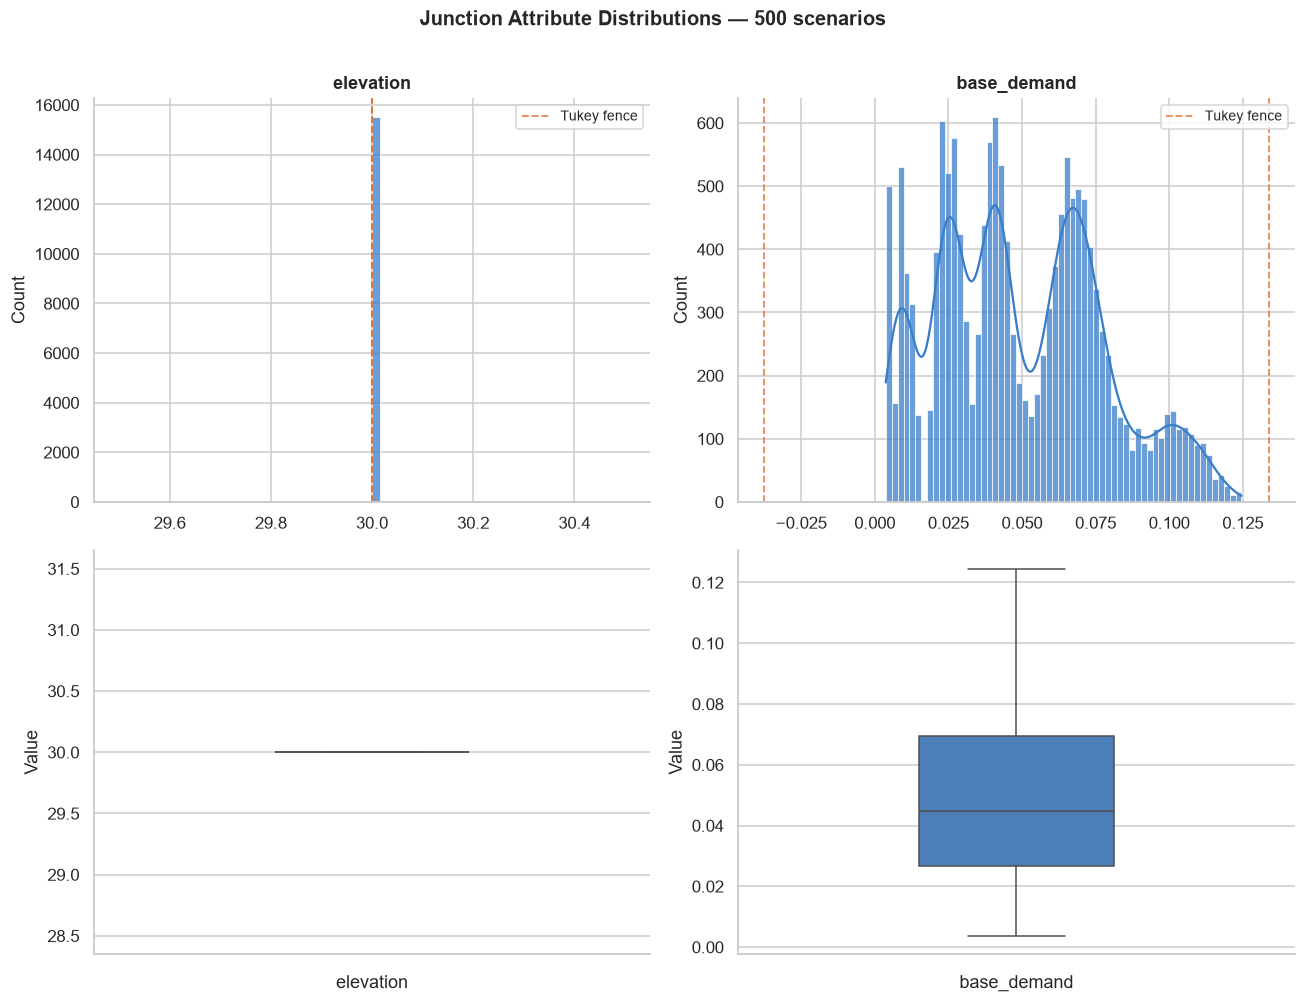

Saved → junction_distributions.png


In [ ]:
JUNC_COLOR = '#3A7DC9'
OUTLIER_COLOR = '#E07030'

cols = list(junc_df.columns)
fig, axes = plt.subplots(2, len(cols), figsize=(6 * len(cols), 9))
fig.suptitle('Junction Attribute Distributions — 500 scenarios', fontsize=13, fontweight='bold', y=1.01)

for i, col in enumerate(cols):
    ax_hist = axes[0, i]
    ax_box  = axes[1, i]

    sns.histplot(junc_df[col], bins=60, kde=True, ax=ax_hist, color=JUNC_COLOR, alpha=0.75)
    ax_hist.set_title(col, fontweight='bold')
    ax_hist.set_xlabel('')
    ax_hist.set_ylabel('Count')

    # IQR fence lines
    q1 = junc_df[col].quantile(0.25)
    q3 = junc_df[col].quantile(0.75)
    iqr = q3 - q1
    for fence in (q1 - 1.5 * iqr, q3 + 1.5 * iqr):
        ax_hist.axvline(fence, color=OUTLIER_COLOR, lw=1.2, ls='--', alpha=0.8, label='Tukey fence')
    handles, labels = ax_hist.get_legend_handles_labels()
    if handles:
        ax_hist.legend(handles[:1], labels[:1], fontsize=9)

    sns.boxplot(
        y=junc_df[col], ax=ax_box, color=JUNC_COLOR, width=0.35,
        flierprops={'marker': 'o', 'markerfacecolor': OUTLIER_COLOR,
                    'markeredgewidth': 0, 'markersize': 2.5, 'alpha': 0.6},
    )
    ax_box.set_xlabel(col)
    ax_box.set_ylabel('Value')

plt.tight_layout()
plt.savefig('junction_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved → junction_distributions.png')

## 6 · Distributions — Pipe attributes

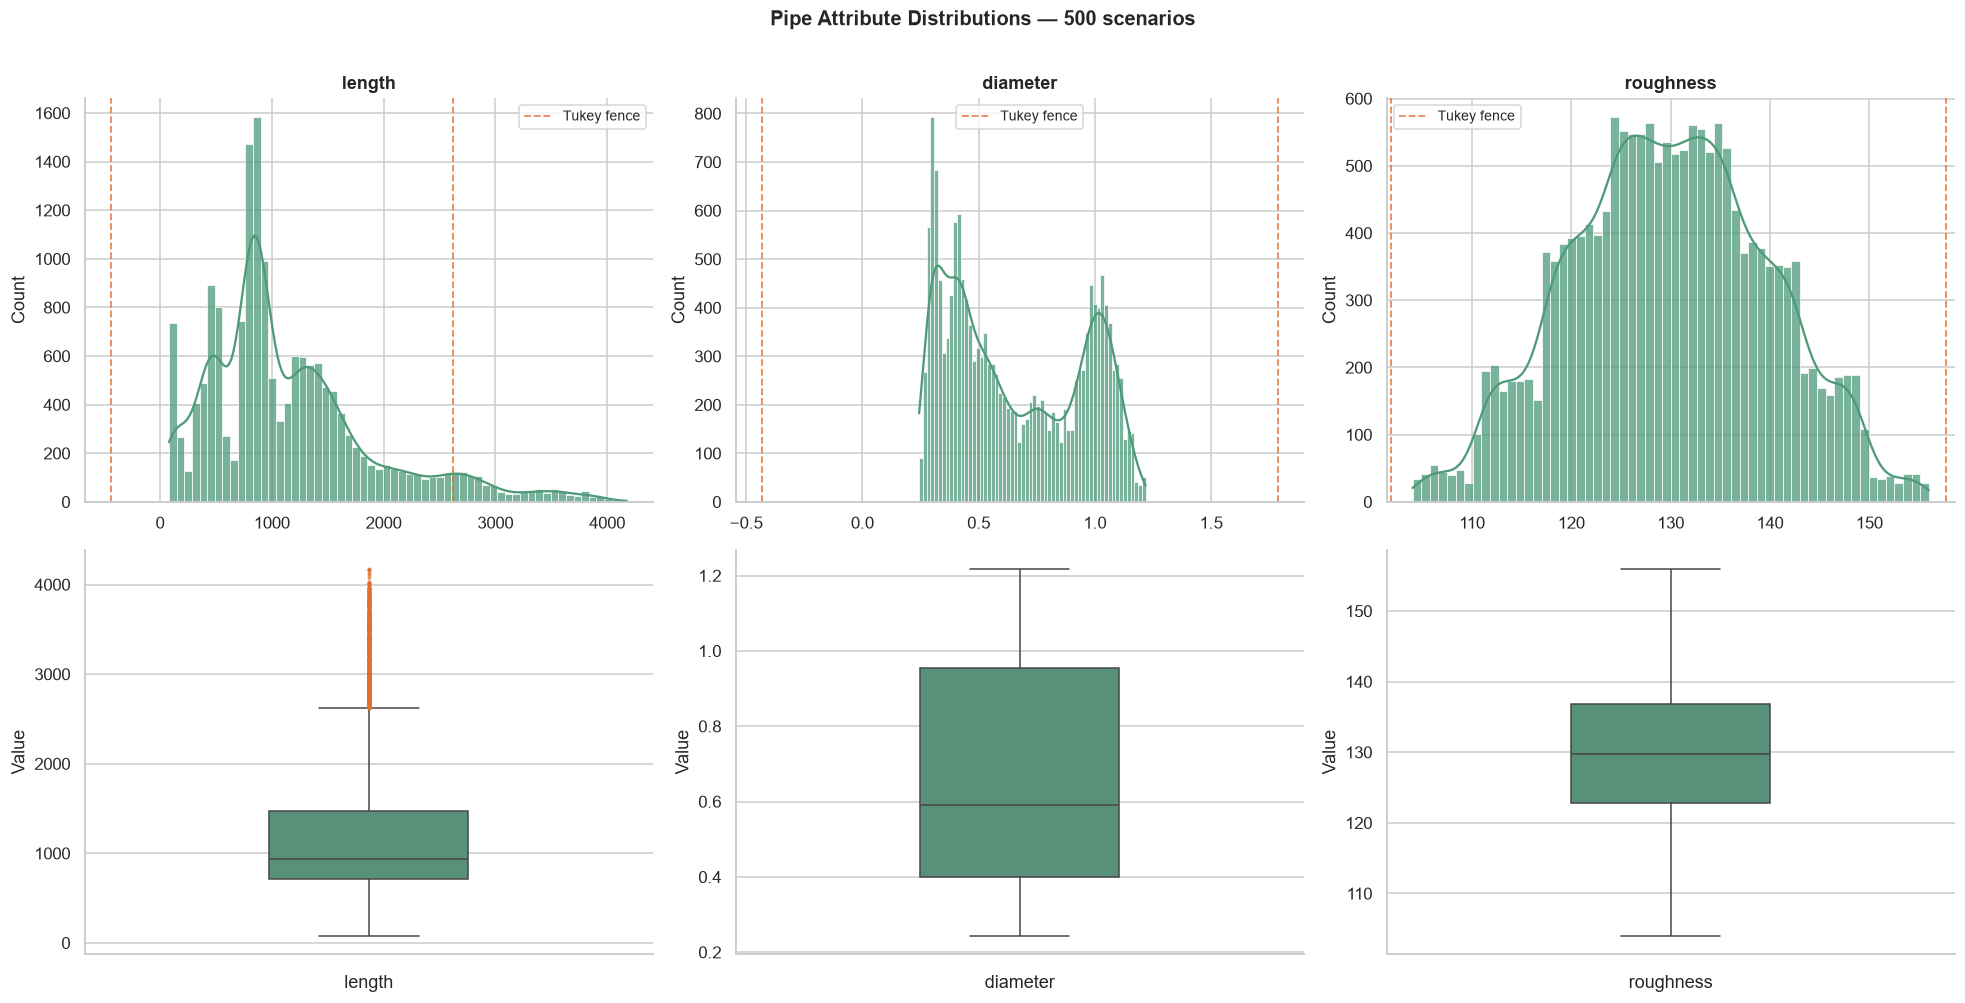

Saved → pipe_distributions.png


In [19]:
PIPE_COLOR = '#4E9A7A'

cols = list(pipe_df.columns)
fig, axes = plt.subplots(2, len(cols), figsize=(6 * len(cols), 9))
fig.suptitle('Pipe Attribute Distributions — 500 scenarios', fontsize=13, fontweight='bold', y=1.01)

for i, col in enumerate(cols):
    ax_hist = axes[0, i]
    ax_box  = axes[1, i]

    sns.histplot(pipe_df[col], bins=60, kde=True, ax=ax_hist, color=PIPE_COLOR, alpha=0.75)
    ax_hist.set_title(col, fontweight='bold')
    ax_hist.set_xlabel('')
    ax_hist.set_ylabel('Count')

    q1, q3 = pipe_df[col].quantile(0.25), pipe_df[col].quantile(0.75)
    iqr = q3 - q1
    for fence in (q1 - 1.5 * iqr, q3 + 1.5 * iqr):
        ax_hist.axvline(fence, color=OUTLIER_COLOR, lw=1.2, ls='--', alpha=0.8, label='Tukey fence')
    handles, labels = ax_hist.get_legend_handles_labels()
    if handles:
        ax_hist.legend(handles[:1], labels[:1], fontsize=9)

    sns.boxplot(
        y=pipe_df[col], ax=ax_box, color=PIPE_COLOR, width=0.35,
        flierprops={'marker': 'o', 'markerfacecolor': OUTLIER_COLOR,
                    'markeredgewidth': 0, 'markersize': 2.5, 'alpha': 0.6},
    )
    ax_box.set_xlabel(col)
    ax_box.set_ylabel('Value')

plt.tight_layout()
plt.savefig('pipe_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved → pipe_distributions.png')

## 7 · Per-node range (between-node spread)
Shows how much each attribute varies *between* nodes within a single scenario —
i.e., the spatial heterogeneity that makes normalization worthwhile.

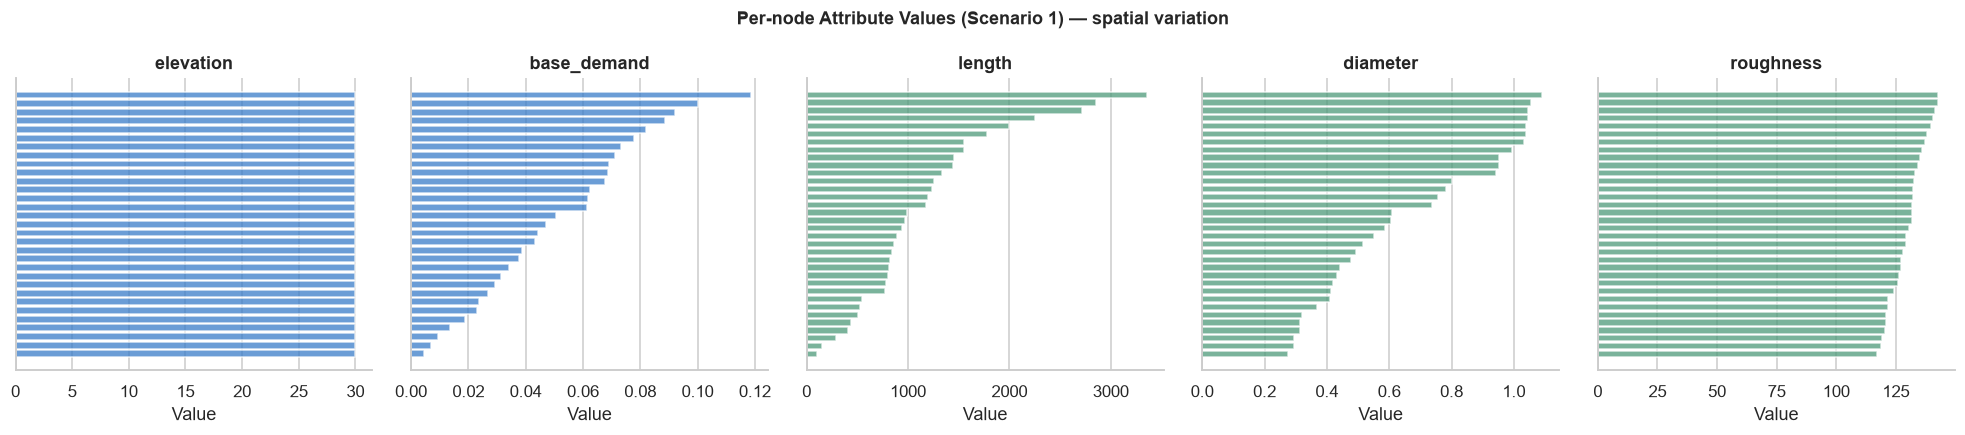

Saved → node_spatial_variation.png


In [20]:
# Use scenario 1 as representative
s1_junc = junc_df.xs(1, level='scenario')
s1_pipe = pipe_df.xs(1, level='scenario')

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Per-node Attribute Values (Scenario 1) — spatial variation', fontsize=12, fontweight='bold')

for ax, (df, col) in zip(axes, [
    (s1_junc, 'elevation'), (s1_junc, 'base_demand'),
    (s1_pipe, 'length'), (s1_pipe, 'diameter'), (s1_pipe, 'roughness'),
]):
    vals = df[col].sort_values()
    ax.barh(range(len(vals)), vals.values,
            color=JUNC_COLOR if col in ('elevation', 'base_demand') else PIPE_COLOR,
            alpha=0.75)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_yticks([])

plt.tight_layout()
plt.savefig('node_spatial_variation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved → node_spatial_variation.png')